# Multitype Cross K-Function and Cross Pair Correlation

This notebook exercises the multitype (two-label) second-order summary
statistics in `nstat.extras.spatial`:
`cross_k_inhom` and `cross_pair_correlation`
(Baddeley-Møller-Waagepetersen 2000).

We build two side-by-side synthetic patterns on the unit square:

1. **Independent labels** — both label classes are drawn from the same
   homogeneous Poisson process and assigned a label independently.  The
   bivariate Poisson null says `K_AB(r) = pi * r**2` and `g_AB(r) = 1`
   at every lag.
2. **Shared-parent Thomas cluster** — a small set of unobserved parents
   produces both label classes via Gaussian offspring kernels with the
   same per-parent intensity, inducing positive cross-correlation that
   the multitype statistic catches at small lags.

References:
- Baddeley AJ, Møller J, Waagepetersen R (2000). *Non- and semi-parametric
  estimation of interaction in inhomogeneous point patterns.* Statistica
  Neerlandica 54(3):329-350.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from nstat.extras.spatial import cross_k_inhom, cross_pair_correlation

rng = np.random.default_rng(20260616)
DOMAIN = ((0.0, 1.0), (0.0, 1.0))
AREA = (DOMAIN[0][1] - DOMAIN[0][0]) * (DOMAIN[1][1] - DOMAIN[1][0])

## Pattern 1 — Independent two-label Poisson

Draw `N` event coordinates uniformly on the unit square, then assign
each event a Bernoulli(0.5) label.  The two label classes are
*independent* inhomogeneous Poisson processes (homogeneous, in this
synthetic case) with constant rate `N/2` events per unit area.

In [2]:
N_INDEP = 600
all_pts = rng.uniform(size=(N_INDEP, 2))
labels = rng.integers(0, 2, size=N_INDEP)
indep_A = all_pts[labels == 0]
indep_B = all_pts[labels == 1]
lambda_A_indep = float(indep_A.shape[0]) / AREA
lambda_B_indep = float(indep_B.shape[0]) / AREA
print({
    'n_A': int(indep_A.shape[0]),
    'n_B': int(indep_B.shape[0]),
    'lambda_A_density': round(lambda_A_indep, 2),
    'lambda_B_density': round(lambda_B_indep, 2),
})

{'n_A': 305, 'n_B': 295, 'lambda_A_density': 305.0, 'lambda_B_density': 295.0}


## Pattern 2 — Thomas-clustered shared-parent labels

Draw `n_parents` parent points uniformly, then for each parent draw
two independent Gaussian-kernel offspring clouds (one per label).
Both label classes share the same parents, so they are cross-correlated
at scales up to the cluster kernel width.

In [3]:
def thomas_offspring(parents, sigma, mean_per_parent, rng):
    counts = rng.poisson(mean_per_parent, size=parents.shape[0])
    offspring = []
    for parent, count in zip(parents, counts):
        if count == 0:
            continue
        offset = rng.normal(scale=sigma, size=(count, 2))
        kids = parent[None, :] + offset
        inside = (
            (kids[:, 0] >= 0.0) & (kids[:, 0] <= 1.0)
            & (kids[:, 1] >= 0.0) & (kids[:, 1] <= 1.0)
        )
        offspring.append(kids[inside])
    return np.vstack(offspring) if offspring else np.zeros((0, 2), dtype=float)

n_parents = 20
parents = rng.uniform(size=(n_parents, 2))
sigma = 0.04
mean_per_parent = 14.0
thomas_A = thomas_offspring(parents, sigma, mean_per_parent, rng)
thomas_B = thomas_offspring(parents, sigma, mean_per_parent, rng)
lambda_A_thomas = float(thomas_A.shape[0]) / AREA
lambda_B_thomas = float(thomas_B.shape[0]) / AREA
print({
    'n_A_clustered': int(thomas_A.shape[0]),
    'n_B_clustered': int(thomas_B.shape[0]),
    'lambda_A_density': round(lambda_A_thomas, 2),
    'lambda_B_density': round(lambda_B_thomas, 2),
})

{'n_A_clustered': 270, 'n_B_clustered': 272, 'lambda_A_density': 270.0, 'lambda_B_density': 272.0}


## Side-by-side scatter

Visual sanity check: the independent labels look like a Poisson
rain across the square; the Thomas clusters concentrate around the
20 unseen parent locations.

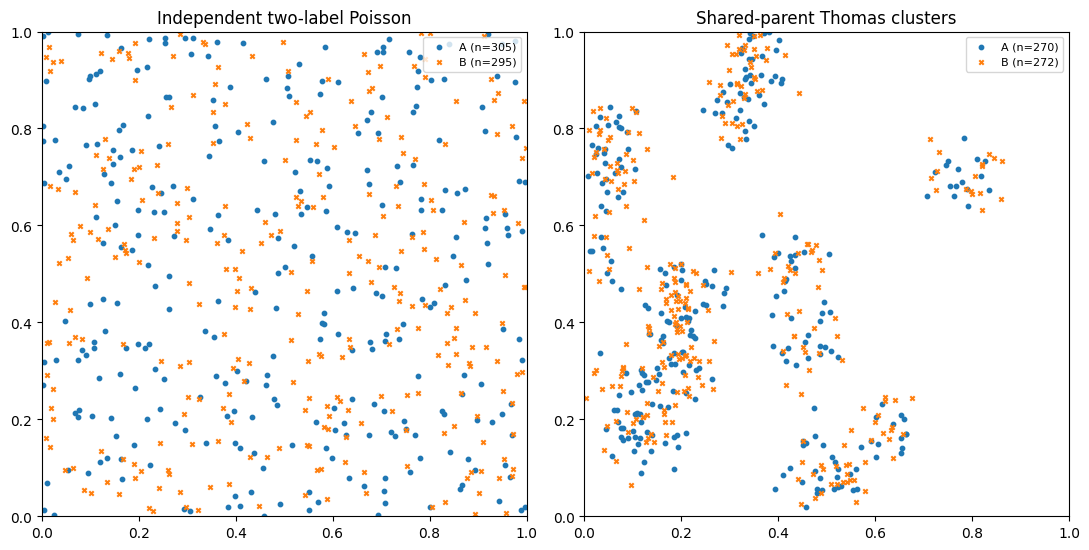

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.5))
axes[0].scatter(indep_A[:, 0], indep_A[:, 1], s=10, color='tab:blue',
                label=f'A (n={indep_A.shape[0]})')
axes[0].scatter(indep_B[:, 0], indep_B[:, 1], s=10, color='tab:orange',
                marker='x', label=f'B (n={indep_B.shape[0]})')
axes[0].set_title('Independent two-label Poisson')
axes[0].set_aspect('equal')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(loc='upper right', fontsize=8)
axes[1].scatter(thomas_A[:, 0], thomas_A[:, 1], s=10, color='tab:blue',
                label=f'A (n={thomas_A.shape[0]})')
axes[1].scatter(thomas_B[:, 0], thomas_B[:, 1], s=10, color='tab:orange',
                marker='x', label=f'B (n={thomas_B.shape[0]})')
axes[1].set_title('Shared-parent Thomas clusters')
axes[1].set_aspect('equal')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

## Cross K-function

`cross_k_inhom` computes the inhomogeneous Ripley K for the pair
(A, B): integrate the cross-pair count up to radius `r` and reweight
by `1 / (lambda_A(x_i) * lambda_B(x_j))`.

Under the bivariate Poisson null the theoretical curve is
`K_AB(r) = pi * r^2` (a 2-D disk area).  We use the constant
homogeneous intensities computed above as the reweighting `lambda_A`,
`lambda_B` — sufficient because both processes are translation-
invariant by construction.

In [5]:
r_grid = np.linspace(0.01, 0.25, 18)
# lambda_A / lambda_B must be a callable X->rate or a per-point array; both
# processes are homogeneous here so we pass per-point constant arrays.
K_indep = cross_k_inhom(
    indep_A, indep_B,
    np.full(indep_A.shape[0], lambda_A_indep),
    np.full(indep_B.shape[0], lambda_B_indep),
    r_grid, domain=DOMAIN, edge_correction='isotropic',
)
K_thomas = cross_k_inhom(
    thomas_A, thomas_B,
    np.full(thomas_A.shape[0], lambda_A_thomas),
    np.full(thomas_B.shape[0], lambda_B_thomas),
    r_grid, domain=DOMAIN, edge_correction='isotropic',
)
K_null = np.pi * r_grid ** 2
print({
    'K_indep_at_r0.10': round(float(np.interp(0.10, r_grid, K_indep)), 4),
    'K_thomas_at_r0.10': round(float(np.interp(0.10, r_grid, K_thomas)), 4),
    'K_null_at_r0.10': round(float(np.pi * 0.10 ** 2), 4),
})

{'K_indep_at_r0.10': 0.0309, 'K_thomas_at_r0.10': 0.0911, 'K_null_at_r0.10': 0.0314}


## Cross pair correlation

The density-form companion of K_AB: kernel-smoothed cross-pair
distance distribution divided by the reweighting product, normalised
so the bivariate Poisson null gives `g_AB(r) = 1` at every lag.

*Confidence: high* on the qualitative reading (cross-attraction at
small `r` for shared-parent Thomas, near-1 across all `r` for the
independent labelling); absolute magnitudes depend on the kernel
bandwidth and the plug-in caveat documented in `spatial_gof`.

In [6]:
g_indep = cross_pair_correlation(
    indep_A, indep_B,
    np.full(indep_A.shape[0], lambda_A_indep),
    np.full(indep_B.shape[0], lambda_B_indep),
    r_grid, bw=0.03, domain=DOMAIN, edge_correction='isotropic',
)
g_thomas = cross_pair_correlation(
    thomas_A, thomas_B,
    np.full(thomas_A.shape[0], lambda_A_thomas),
    np.full(thomas_B.shape[0], lambda_B_thomas),
    r_grid, bw=0.03, domain=DOMAIN, edge_correction='isotropic',
)
print({
    'g_indep_at_r0.05': round(float(np.interp(0.05, r_grid, g_indep)), 3),
    'g_thomas_at_r0.05': round(float(np.interp(0.05, r_grid, g_thomas)), 3),
})

{'g_indep_at_r0.05': 0.979, 'g_thomas_at_r0.05': 3.302}


## Side-by-side summary statistics

Left: `K_AB(r)` for both patterns plus the bivariate Poisson null.
Right: `g_AB(r)` for both patterns plus the `g = 1` reference.

The independent-labelling traces hug the null on both panels.  The
shared-parent Thomas traces depart upward at small `r` — the multi-
type statistics detect cross-attraction at the cluster-kernel scale.

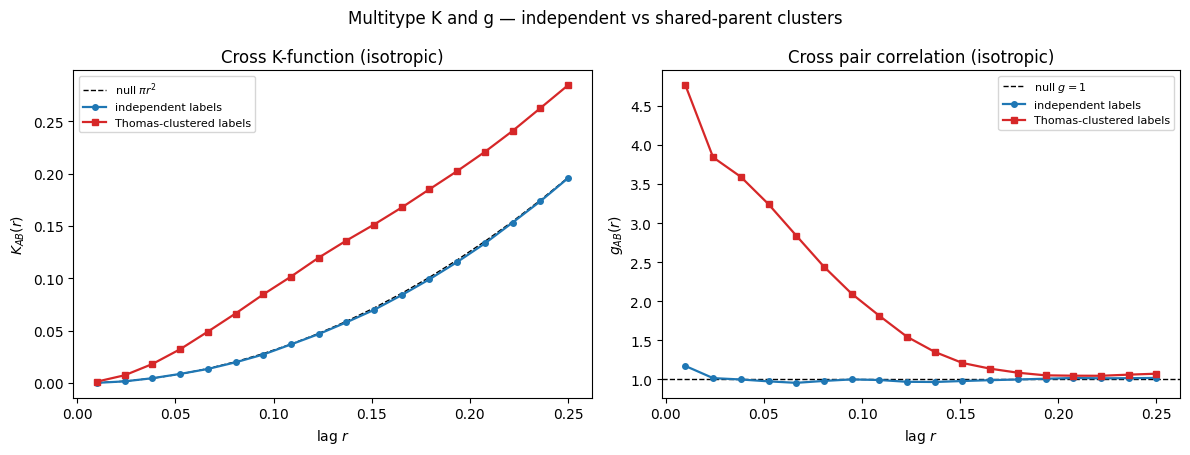

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].plot(r_grid, K_null, 'k--', lw=1.0, label=r'null $\pi r^2$')
axes[0].plot(r_grid, K_indep, color='tab:blue', lw=1.6, marker='o', ms=4,
             label='independent labels')
axes[0].plot(r_grid, K_thomas, color='tab:red', lw=1.6, marker='s', ms=4,
             label='Thomas-clustered labels')
axes[0].set_xlabel('lag $r$')
axes[0].set_ylabel(r'$K_{AB}(r)$')
axes[0].set_title('Cross K-function (isotropic)')
axes[0].legend(loc='upper left', fontsize=8)

axes[1].axhline(1.0, color='k', ls='--', lw=1.0, label=r'null $g = 1$')
axes[1].plot(r_grid, g_indep, color='tab:blue', lw=1.6, marker='o', ms=4,
             label='independent labels')
axes[1].plot(r_grid, g_thomas, color='tab:red', lw=1.6, marker='s', ms=4,
             label='Thomas-clustered labels')
axes[1].set_xlabel('lag $r$')
axes[1].set_ylabel(r'$g_{AB}(r)$')
axes[1].set_title('Cross pair correlation (isotropic)')
axes[1].legend(loc='upper right', fontsize=8)
fig.suptitle('Multitype K and g — independent vs shared-parent clusters')
fig.tight_layout()
plt.show()

## Takeaways

- `cross_k_inhom` and `cross_pair_correlation` are the two-label
  analogues of `k_inhom` and `pair_correlation`.  Both accept the
  Ripley `edge_correction` modes added in Tier D / Tier E.
- Under independent inhomogeneous Poisson labels, both statistics
  collapse to their analytic nulls; deviations are signed evidence of
  cross-attraction (`> null`) or cross-repulsion (`< null`).
- The same plug-in caveat as the single-type estimators applies: when
  the reweighting intensities are fit to the same data, the apparent
  agreement with the null is optimistic.  Hold out a chunk of the
  data for the intensity fit, or pass an analytic ground-truth
  `lambda` as we do here.